# Homework Assignment 3 (40 points)

# Submission Rules

#### 제출기한: **2026년 5월 3일 (일) 23:00까지** (제출 기한 엄수)
- 제출방법 고려대학교 LMS (lms.korea.ac.kr) 과목 > 주차학습 > 과제 및 평가

#### 제목형식
- 보고서 파일: DAS509_hw3_이름.pdf (파일형식은 **반드시 pdf**)
- 코드 파일: DAS509_hw3_이름.ipynb (jupyter notebook이 아닌 경우 다른 확장자 가능)

## 문제 1 - `Country-data.csv` 데이터 분석 (15점)

167개국에 대해서 사회/경제적 상황을 확인할 수 있는 9개의 변수를 기록한 `Country-data.csv` 데이터에 대해 다음의 작업을 수행하라.

(a) 각 변수의 분포를 확인하고, 필요한 경우 개별 변수의 분포를 최대한 정규분포에 가깝게 변환하고, 표준화하라. 

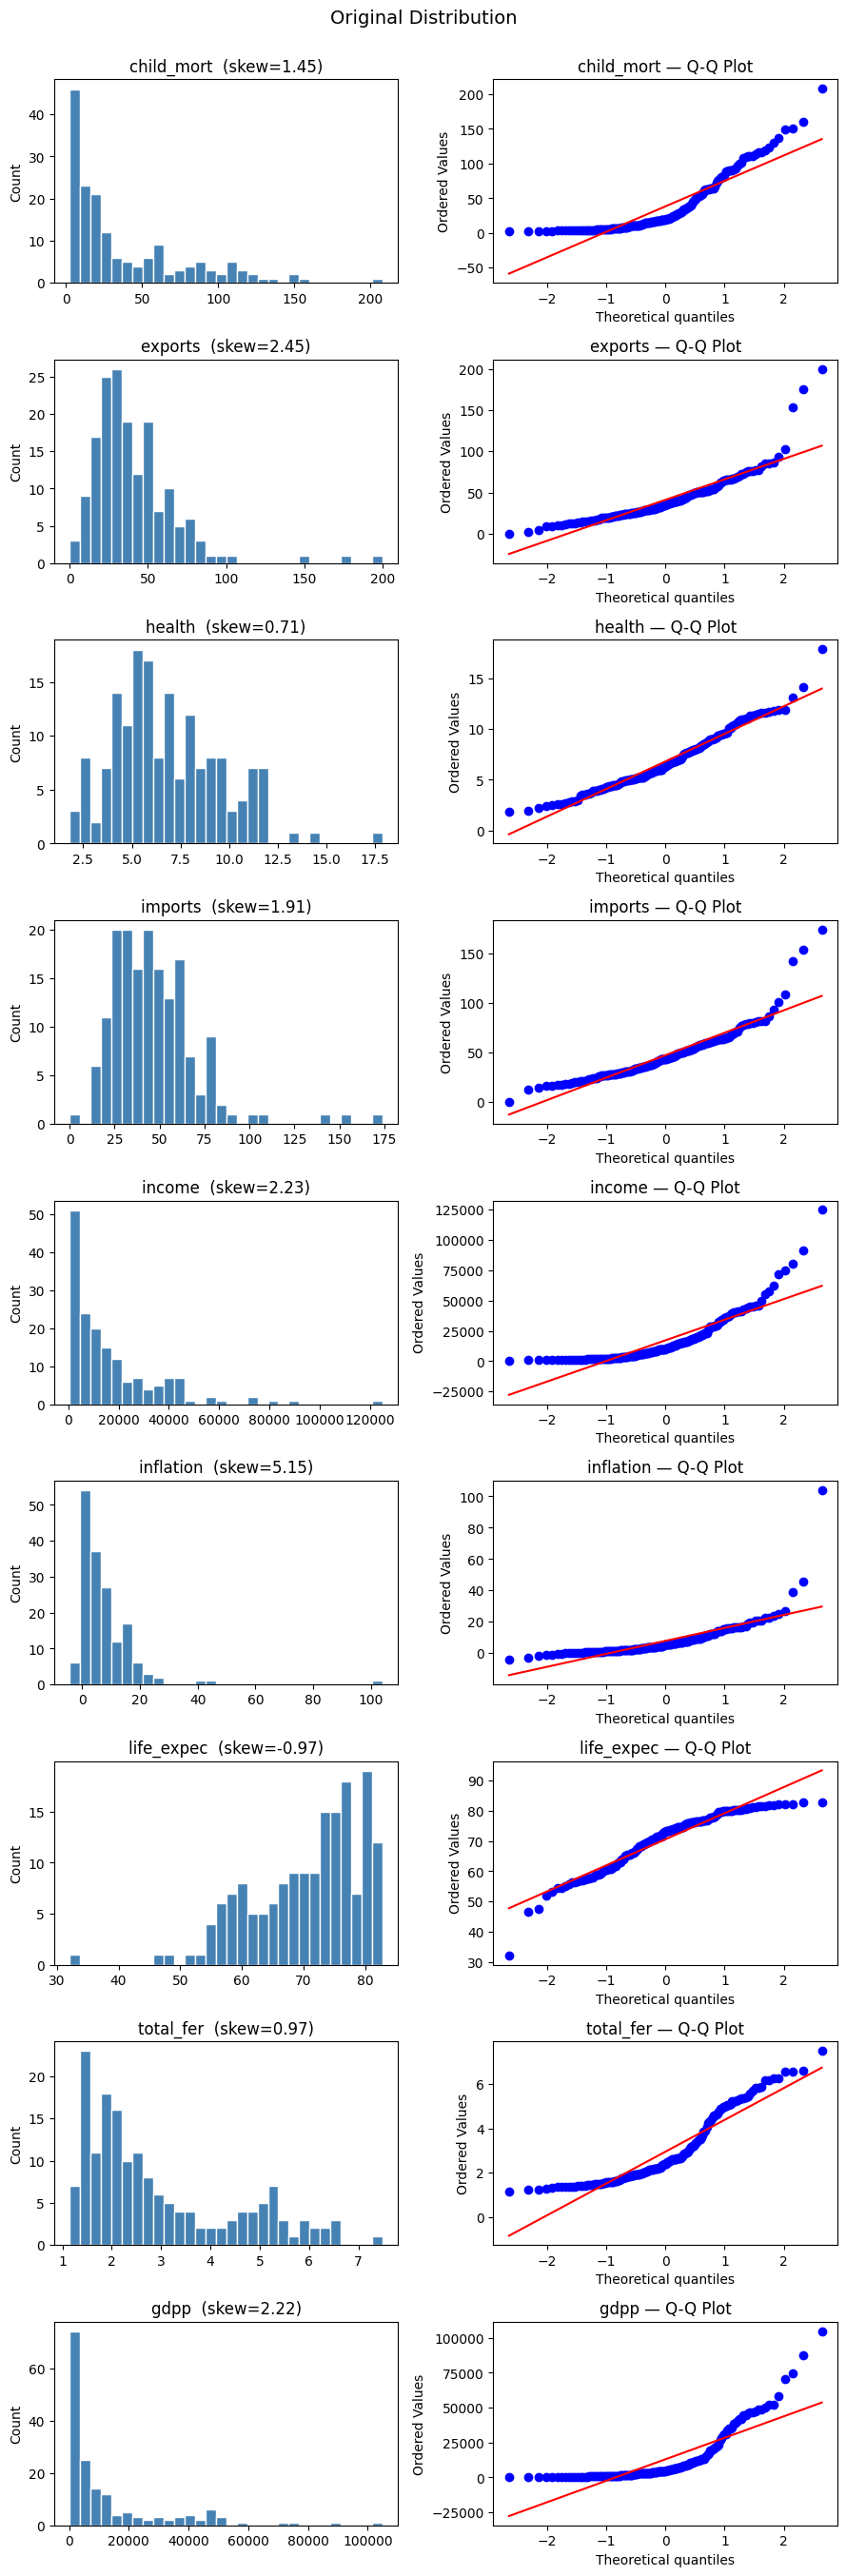

child_mort  : Box-Cox 변환 (λ=0.0092, skew 1.45 → -0.00)
exports     : Box-Cox 변환 (λ=0.3583, skew 2.45 → 0.19)
health      : 변환 없음 (skew=0.71)
imports     : Box-Cox 변환 (λ=0.447, skew 1.91 → 0.27)
income      : Box-Cox 변환 (λ=0.098, skew 2.23 → -0.04)
inflation   : Box-Cox 변환 (λ=-0.038, skew 5.15 → -0.01)
life_expec  : Box-Cox 변환 (λ=3.7171, skew -0.97 → -0.19)
total_fer   : Box-Cox 변환 (λ=-0.4791, skew 0.97 → 0.09)
gdpp        : Box-Cox 변환 (λ=-0.002, skew 2.22 → 0.00)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Country-data.csv')
features = df.columns[1:]
X = df[features].copy()

#1. 원본 개별 변수의 분포 확인
fig, axes = plt.subplots(9, 2, figsize=(9, 27))
fig.suptitle('Original Distribution', fontsize=14, y=1.001)

for i, col in enumerate(features):
    # 히스토그램 (전체분포)
    axes[i, 0].hist(X[col], bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col}  (skew={X[col].skew():.2f})')
    axes[i, 0].set_ylabel('Count')

    # Q-Q Plot (정규분포와의 편차)
    stats.probplot(X[col], dist='norm', plot=axes[i, 1])
    axes[i, 1].set_title(f'{col} — Q-Q Plot')

plt.tight_layout()
plt.show()

#2. 개별 변수 분포를 최대한 정규분포에 가깝게 변환
# 변수 변환 기준 : 시각적 확인(히스토그램, Q-Q Plot)과 수치 기준을 함께 활용하였다. 
# 일반적으로 |skew| > 1을 변환 기준으로 사용하나, 
# Q-Q Plot에서 life_expec는 꼬리 부분이 정규분포에서 벗어나고, total_fer는 S자형 분포를 띄는 것으로 확인되어 
# 기준을 |skew| > 0.8로 조정하였음

X_trans = X.copy()
lambdas = {}
for col in features:
    skew_val = abs(float(X[col].skew()))
    if skew_val > 0.8:
        col_min = X[col].min()
        if col_min <= 0:
            shifted = X[col] - col_min + 1  # 양수로 shift
            X_trans[col], lam = stats.boxcox(shifted)
        else:
            X_trans[col], lam = stats.boxcox(X[col])
        lambdas[col] = round(lam, 4)
        print(f'{col:12s}: Box-Cox 변환 (λ={lambdas[col]}, skew {X[col].skew():.2f} → {X_trans[col].skew():.2f})')
    else:
        print(f'{col:12s}: 변환 없음 (skew={X[col].skew():.2f})')


#3. 표준화 
X_scaled = StandardScaler().fit_transform(X_trans)
X_scaled = pd.DataFrame(X_scaled, columns=features)



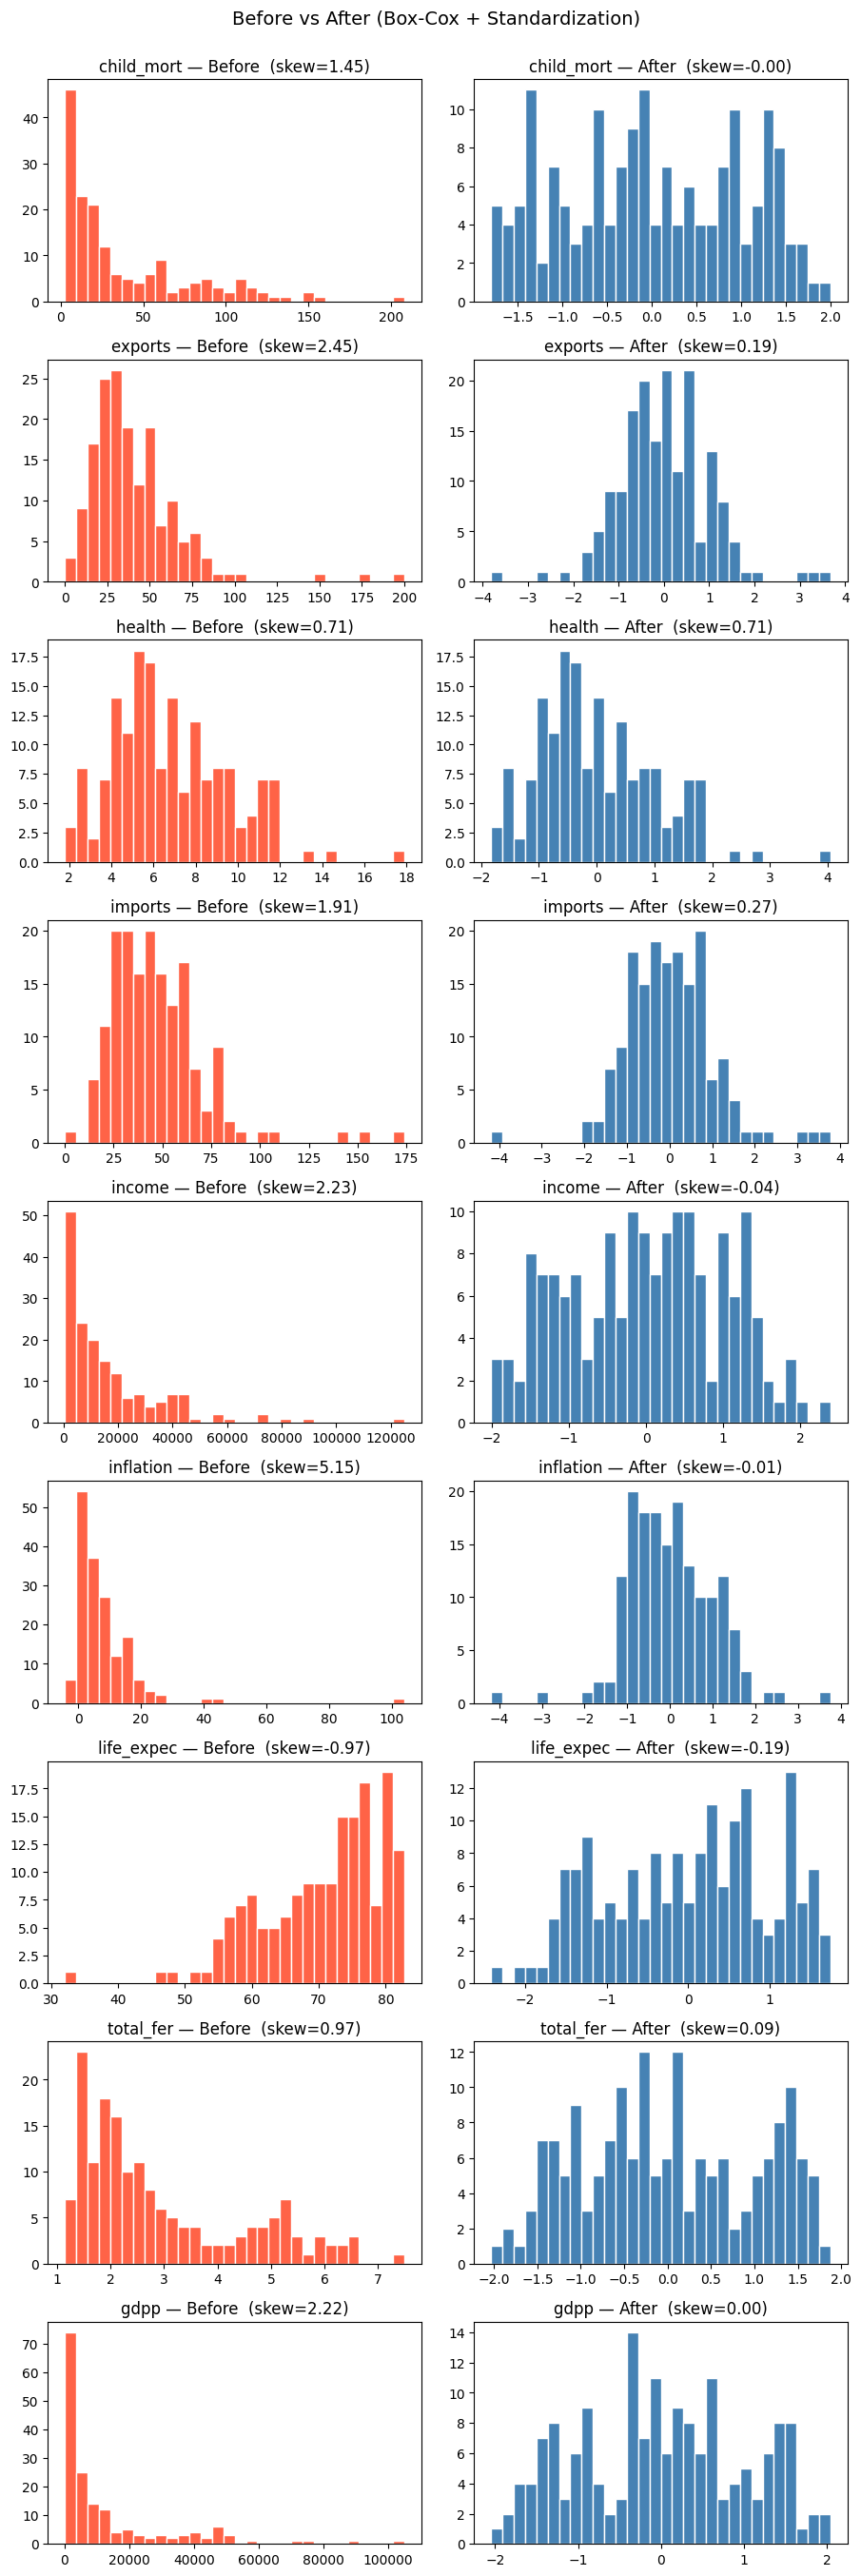

In [2]:
# (확인용) 변환 전/후 비교 시각화
fig, axes = plt.subplots(9, 2, figsize=(9,27))
fig.suptitle('Before vs After (Box-Cox + Standardization)', fontsize=14, y=1.001)

for i, col in enumerate(features):
    # 변환 전
    axes[i, 0].hist(X[col], bins=30, color='tomato', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Before  (skew={X[col].skew():.2f})')

    # 변환 후 (표준화까지 완료된 값)
    axes[i, 1].hist(X_scaled[col], bins=30, color='steelblue', edgecolor='white')
    axes[i, 1].set_title(f'{col} — After  (skew={X_scaled[col].skew():.2f})')

plt.tight_layout()
plt.show()

(b) 표준화된 변수에 주성분 분석(PCA)를 실시하여 2차원 변수로 변환하고 시각화하라. 

(참고) 설명분산 비율: [0.551 0.167 0.132 0.07  0.04  0.021 0.011 0.006 0.002]
(참고) 누적 설명분산: [0.551 0.718 0.85  0.92  0.96  0.981 0.992 0.998 1.   ]
        PC1       PC2              country
0  3.415082 -0.189295          Afghanistan
1 -0.633574 -0.221418              Albania
2  0.339938 -0.519732              Algeria
3  2.396101  1.047432               Angola
4 -1.482676  0.497085  Antigua and Barbuda


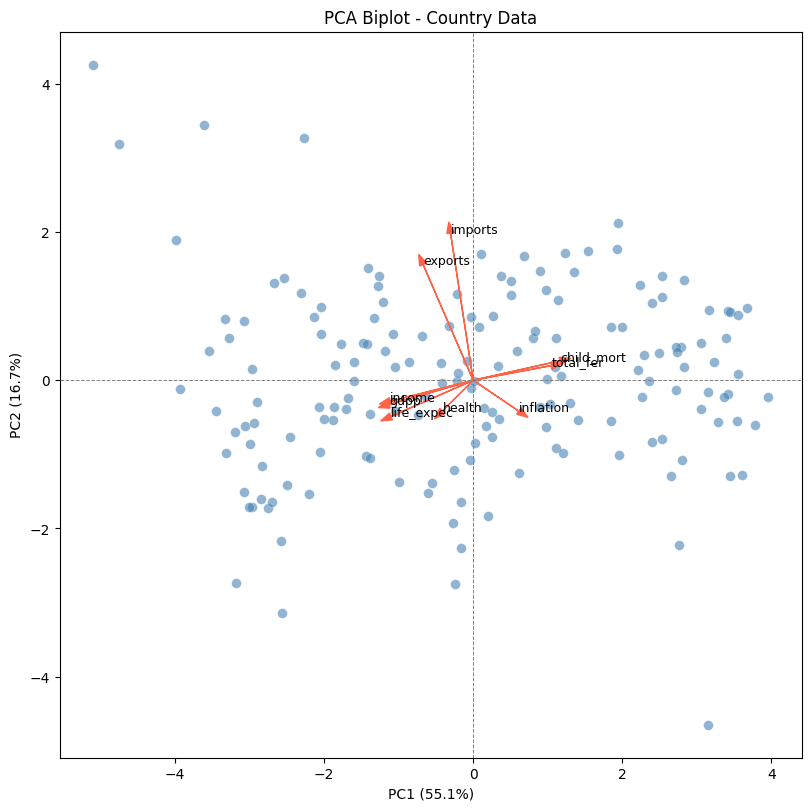

In [3]:
from sklearn.decomposition import PCA

# (참고) PCA 설명분산 확인
# PC1, PC2로 누적 71.8%의 분산이 설명됨
pca_full = PCA(n_components=9)
pca_full.fit(X_scaled)
ratio = pca_full.explained_variance_ratio_
print('(참고) 설명분산 비율:', np.round(ratio, 3))
print('(참고) 누적 설명분산:', np.round(np.cumsum(ratio), 3))

# 1. PCA를 통해 2차원 변수로 변환 
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pca_scores, columns=['PC1', 'PC2'])
df_pca['country'] = df['country'].values
print(df_pca.head())


#2. 시각화 
a = pca.components_.T  # loading vector
fig, ax = plt.subplots(figsize=(8, 8), layout='constrained')
ax.scatter(df_pca['PC1'], df_pca['PC2'],
           alpha=0.6, s=50, color='steelblue',
           edgecolors='white', lw=0.3)

scale = np.std(pca_scores) * 1.5  # 데이터 퍼짐 정도에 맞게 자동 조정

for i, col in enumerate(features):
    ax.arrow(x=0, y=0,
             dx=scale * a[i, 0],   # ← 3 → scale 로 교체
             dy=scale * a[i, 1],
             color='tomato', head_width=0.1)
    ax.text(scale * a[i, 0], scale * a[i, 1], col, fontsize=9)

ax.axhline(0, color='grey', lw=0.7, ls='--')
ax.axvline(0, color='grey', lw=0.7, ls='--')
ax.set_xlabel(f'PC1 ({ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ratio[1]*100:.1f}%)')
ax.set_title('PCA Biplot - Country Data')
plt.show()




(c) 축소된 2차원 변수에 대해 군집 분석을 실시하고, 각 군집에 속한 국가를 확인하여 군집의 의미를 해석해보아라. 

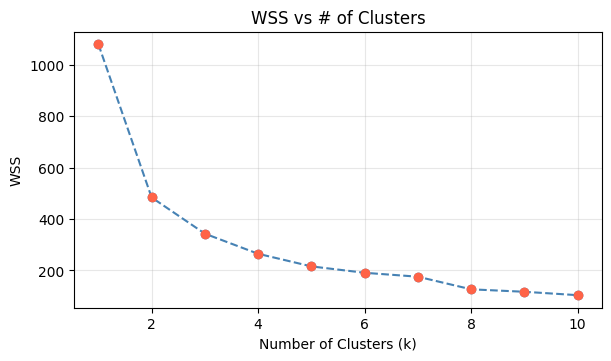

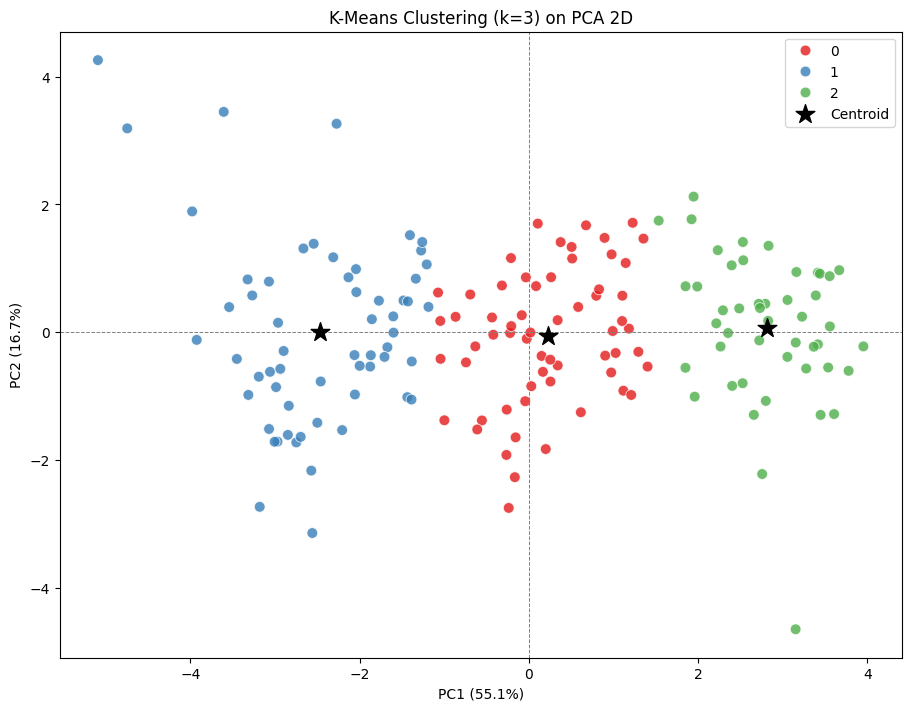

=== 군집별 국가 수 ===
cluster
0    61
1    59
2    47
Name: count, dtype: int64

=== 군집별 주요 변수 평균 ===
         child_mort  exports  health  imports   income  inflation  life_expec  \
cluster                                                                         
0              27.6     38.6     6.0     43.8  11812.5        9.9        71.0   
1               7.0     56.4     8.2     54.2  34515.6        2.5        78.5   
2              91.4     25.1     6.2     41.8   2259.2       11.6        60.1   

         total_fer     gdpp  
cluster                      
0              2.6   5718.8  
1              1.7  29987.6  
2              4.9    997.8  

=== 군집별 대표 국가 ===
Cluster 0 대표 국가: ['Jamaica', 'El Salvador', 'Morocco']
Cluster 1 대표 국가: ['Cyprus', 'South Korea', 'Poland']
Cluster 2 대표 국가: ['Zambia', 'Cameroon', 'Gambia']


In [4]:
from sklearn.cluster import KMeans
import seaborn as sns

# K-means 군집 분석
# Scree Plot에서 elbow 확인 후 k 결정
# Step 1: 최적 군집 수 탐색 (WSS Scree Plot)
wss = []
for k in range(1, 11):
    kms = KMeans(n_clusters=k, random_state=42)
    kms.fit(pca_scores)
    wss.append(kms.inertia_)   # 군집내 제곱합

fig, ax = plt.subplots(figsize=(6, 3.5), layout='constrained')
ax.plot(range(1, 11), wss, 'o--', color='steelblue')
ax.scatter(range(1, 11), wss, color='tomato', zorder=5)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('WSS')
ax.set_title('WSS vs # of Clusters')
ax.grid(True, alpha=0.3)
plt.show()

# Step 2: k=3으로 군집화 수행
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(pca_scores)
labels = km.labels_
centers = km.cluster_centers_

# 결과 DataFrame
kmeans_df = pd.DataFrame(pca_scores, columns=['PC1', 'PC2'])
kmeans_df['cluster'] = labels
kmeans_df['country'] = df['country'].values


#Step 3: 군집 결과 시각화 
fig, ax = plt.subplots(figsize=(9, 7), layout='constrained')

sns.scatterplot(data=kmeans_df, x='PC1', y='PC2',
                hue='cluster', palette='Set1',
                s=60, alpha=0.8, ax=ax)

# 군집 중심점
ax.scatter(centers[:, 0], centers[:, 1],
           c='black', marker='*', s=200, zorder=5, label='Centroid')

ax.axhline(0, color='grey', lw=0.7, ls='--')
ax.axvline(0, color='grey', lw=0.7, ls='--')
ax.set_xlabel(f'PC1 ({ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ratio[1]*100:.1f}%)')
ax.set_title('K-Means Clustering (k=3) on PCA 2D')
ax.legend()
plt.show()

# Step 4: 군집별 원변수 평균으로 해석  
df['cluster'] = labels

print('=== 군집별 국가 수 ===')
print(df['cluster'].value_counts().sort_index())

print('\n=== 군집별 주요 변수 평균 ===')
print(df.groupby('cluster')[list(features)].mean().round(1))

print('\n=== 군집별 대표 국가 ===')
# 군집 중심에 가장 가까운 국가 3개씩 추출

from scipy.spatial.distance import cdist
# pca_scores 기준으로 각 국가와 centroid 간 거리 계산
for c in range(3):
    # 해당 군집에 속한 국가 인덱스
    cluster_idx = np.where(labels == c)[0]
    
    # 해당 군집 중심과의 거리 계산
    distances = cdist(pca_scores[cluster_idx], 
                      centers[c].reshape(1, -1), 
                      metric='euclidean').flatten()
    
    # 거리 가장 가까운 3개 인덱스
    top3_idx = cluster_idx[np.argsort(distances)[:3]]
    top3_countries = df['country'].iloc[top3_idx].tolist()
    
    print(f'Cluster {c} 대표 국가: {top3_countries}')

# 의미 해석은 하단의 별도 마크다운 셀에 작성하였습니다.

#### <군집별 의미 해석>

[Cluster0] 중진국 (개발도상국) — 중간 수준의 소득과 기대수명, 낮지 않은 영아사망률 (ex. 자메이카, 모로코 등)

[Cluster1] 선진국 (고소득국가) - 높은 소득과 기대수명, 낮은 영아사망률과 출산율, 낮은 인플레이션 (ex. 한국, 폴란드 등)

[Cluster2] 저개발국 (저소득국) — 매우 낮은 소득, 높은 영아사망률과 출산율, 낮은 기대수명 (ex. 잠비아, 카메룬 등)

#### <주요 변수>

gdpp와 income → 소득 수준의 차이가 군집을 가장 잘 설명

child_mort와 life_expec → 소득 수준과 강하게 연동, 저개발국일수록 영아사망률 높고 기대수명 낮음

total_fer → 저개발국(4.9)이 선진국(1.7)의 약 3배, 소득이 낮을수록 출산율 높은 패턴

inflation → Cluster 2(저개발국 11.6)가 Cluster 1(선진국 2.5)보다 약 5배 높음, 경제 불안정성 반영

## 문제 2 - 주식 데이터 분석 (15점)

파이썬 `FinanceDataReader` 라이브러리를 활용하여. 미국 증시 (NASDAQ)에 상장된 기업 10개와 한국 증시 (KOSPI)에 상장된 기업 10개, 총 20개의 기업을 선택하여 2025/1/1 - 2025/12/31 동안의 주가를 다운로드하자. 각 증시에 상장된 기업의 리스트는 아래의 코드로 확인 가능하다. 

In [5]:
#pip3 install -U finance-datareader
import FinanceDataReader as fdr

# 미국 NASDAQ에 상장된 기업의 List
nasdaq_list = fdr.StockListing('NASDAQ')
nasdaq_list.head(10)

100%|██████████| 3866/3866 [00:06<00:00, 622.11it/s]


,Symbol,Name,IndustryCode,Industry
0,NVDA,NVIDIA Corp,57101010,반도체
1,AAPL,Apple Inc,57106020,전화 및 소형 장치
2,MSFT,Microsoft Corp,57201020,소프트웨어
3,AMZN,Amazon.com Inc,53402010,백화점
4,GOOGL,Alphabet Inc Class A,57201030,온라인 서비스
5,AVGO,Broadcom Inc,57101010,반도체
6,GOOG,Alphabet Inc Class C,57201030,온라인 서비스
7,META,Meta Platforms Inc,57201030,온라인 서비스
8,TSLA,Tesla Inc,53101010,자동차 및 트럭 제조
9,WMT,Walmart Inc,54301020,식품 소매 및 유통


위 코드가 작동하지 않을 경우 다음의 정보를 활용한다. 

순위,기업명,종목 코드,주요 섹터,비고

1,삼성전자,005930,반도체,KRX 대장주

2,SK하이닉스,000660,반도체,메모리 반도체

3,LG에너지솔루션,373220,2차전지,배터리 제조

4,삼성바이오로직스,207940,바이오,위탁생산(CMO)

5,현대차,005380,자동차,완성차 제조

6,기아,000270,자동차,완성차 제조

7,셀트리온,068270,바이오,바이오시밀러

8,KB금융,105560,금융,금융지주

9,NAVER,035420,서비스,IT 플랫폼

10,신한지주,055550,금융,금융지주

가령 삼성전자의 주가에 대한 정보는 다음과 같이 확인할 수 있다. 

In [6]:
samsung = fdr.DataReader('005930', '2025-01-01', '2025-12-31')
samsung.head(10)

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-01-02,52700,53600,52300,53400,16630538,0.003759
2025-01-03,52800,55100,52800,54400,19318046,0.018727
2025-01-06,54400,56200,54300,55900,19034284,0.027574
2025-01-07,56800,57300,55400,55400,17030235,-0.008945
2025-01-08,54800,57500,54700,57300,26593553,0.034296
2025-01-09,57600,57700,56100,56100,24490592,-0.020942
2025-01-10,56100,56500,55200,55300,16059223,-0.014260
2025-01-13,54600,55000,54100,54100,16868600,-0.021700
2025-01-14,54200,54600,53700,53900,17465926,-0.003697


In [7]:
# 기업별 원본 데이터  
nasdaq_tickers = dict(zip(nasdaq_list['Symbol'].head(10),
                          nasdaq_list['Name'].head(10)))

START, END_load = '2025-01-01', '2026-01-01'

# KOSPI 10개
kospi_tickers = {
    '005930': '삼성전자',
    '000660': 'SK하이닉스',
    '373220': 'LG에너지솔루션',
    '207940': '삼성바이오로직스',
    '005380': '현대차',
    '000270': '기아',
    '068270': '셀트리온',
    '105560': 'KB금융',
    '035420': 'NAVER',
    '055550': '신한지주'
}

nasdaq_data = pd.concat(
    {name: fdr.DataReader(ticker, START, END_load).loc[START:]  # ← START~END 범위
     for ticker, name in nasdaq_tickers.items()},
    axis=0
)

kospi_data = pd.concat(
    {name: fdr.DataReader(ticker, START, END_load).loc[START:]  # ← START~END 범위
     for ticker, name in kospi_tickers.items()},
    axis=0
)

In [8]:
print('=== NASDAQ ===')
print(nasdaq_data.tail())
print('\n=== KOSPI ===')
print(kospi_data.tail())

=== NASDAQ ===
                              Open        High         Low       Close  \
Walmart Inc 2025-12-24  110.900002  111.709999  110.550003  111.610001   
            2025-12-26  111.720001  111.970001  111.360001  111.739998   
            2025-12-29  111.589996  112.779999  111.570000  112.529999   
            2025-12-30  111.889999  112.690002  111.839996  111.919998   
            2025-12-31  111.730003  112.250000  111.320000  111.410004   

                          Volume   Adj Close  
Walmart Inc 2025-12-24   9009600  111.381416  
            2025-12-26   9003800  111.511147  
            2025-12-29  12979600  112.299530  
            2025-12-30  11730600  111.690781  
            2025-12-31  11487400  111.181831  

=== KOSPI ===
                  Open   High    Low  Close  Volume    Change
     Date                                                    
신한지주 2025-12-23  78200  78500  75900  76500  712754 -0.026718
     2025-12-24  77100  78100  77100  77800  667157  0.01

(a) 각 기업별로 평균가 (= (`High` + `Low`) / 2)를 계산하고, 2025년 첫 영업일의 주가를 100으로 표준화 (or 지수화)한 데이터를 생성하라.

In [9]:
nasdaq_data['AVG'] = (nasdaq_data['High'] + nasdaq_data['Low']) / 2
nasdaq_data['표준화'] = nasdaq_data.groupby(level=0)['AVG'].transform(lambda x: x / x.iloc[0] * 100)

kospi_data['AVG'] = (kospi_data['High'] + kospi_data['Low']) / 2
kospi_data['표준화'] = kospi_data.groupby(level=0)['AVG'].transform(lambda x: x / x.iloc[0] * 100)

print(nasdaq_data.head())
print(kospi_data.head())

                              Open        High         Low       Close  \
NVIDIA Corp 2025-01-02  136.000000  138.880005  134.630005  138.309998   
            2025-01-03  140.009995  144.899994  139.729996  144.470001   
            2025-01-06  148.589996  152.160004  147.820007  149.429993   
            2025-01-07  153.029999  153.130005  140.009995  140.139999   
            2025-01-08  142.580002  143.949997  137.559998  140.110001   

                           Volume   Adj Close         AVG         표준화  
NVIDIA Corp 2025-01-02  198247200  138.264709  136.755005  100.000000  
            2025-01-03  229322500  144.422684  142.314995  104.065657  
            2025-01-06  265377400  149.381042  149.990005  109.677891  
            2025-01-07  351782200  140.094086  146.570000  107.177064  
            2025-01-08  227349900  140.064102  140.754997  102.924933  
                  Open   High    Low  Close    Volume    Change      AVG  \
     Date                                      

(b) 미국의 5개 기업의 주가데이터와 한국의 5개 기업의 주가데이터에 각각 차원축소 방법을 적용하여, 1차원 변수로 변환하라.

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# NASDAQ 상위 5개, KOSPI 상위 5개
nasdaq_5 = list(nasdaq_tickers.values())[:5]
kospi_5  = list(kospi_tickers.values())[:5]

# ── NASDAQ: 5개 기업의 표준화 주가를 열로 모아서 행렬 구성
#    shape: (거래일 수 × 5)
nasdaq_matrix = pd.concat(
    [nasdaq_data.loc[name]['표준화'].rename(name) for name in nasdaq_5],
    axis=1
).dropna()

nasdaq_scaled = StandardScaler().fit_transform(nasdaq_matrix)
pca_nq = PCA(n_components=1)
nasdaq_pc1 = pd.DataFrame(
    pca_nq.fit_transform(nasdaq_scaled),
    index=nasdaq_matrix.index,
    columns=['NASDAQ_PC1']
)
print(f'NASDAQ PC1 설명분산: {pca_nq.explained_variance_ratio_[0]*100:.1f}%')
print(f'NASDAQ loadings:\n{pd.Series(pca_nq.components_[0], index=nasdaq_5).round(3)}')

# ── KOSPI: 동일하게
#    shape: (거래일 수 × 5)
kospi_matrix = pd.concat(
    [kospi_data.loc[name]['표준화'].rename(name) for name in kospi_5],
    axis=1
).dropna()

kospi_scaled = StandardScaler().fit_transform(kospi_matrix)
pca_kp = PCA(n_components=1)
kospi_pc1 = pd.DataFrame(
    pca_kp.fit_transform(kospi_scaled),
    index=kospi_matrix.index,
    columns=['KOSPI_PC1']
)
print(f'\nKOSPI PC1 설명분산: {pca_kp.explained_variance_ratio_[0]*100:.1f}%')
print(f'KOSPI loadings:\n{pd.Series(pca_kp.components_[0], index=kospi_5).round(3)}')

print('\n=== NASDAQ PC1 ===')
print(nasdaq_pc1.head())
print('\n=== KOSPI PC1 ===')
print(kospi_pc1.head())

NASDAQ PC1 설명분산: 75.5%
NASDAQ loadings:
NVIDIA Corp             0.489
Apple Inc               0.423
Microsoft Corp          0.419
Amazon.com Inc          0.437
Alphabet Inc Class A    0.464
dtype: float64

KOSPI PC1 설명분산: 83.2%
KOSPI loadings:
삼성전자        0.466
SK하이닉스      0.472
LG에너지솔루션    0.439
삼성바이오로직스    0.387
현대차         0.467
dtype: float64

=== NASDAQ PC1 ===
            NASDAQ_PC1
2025-01-02   -0.516674
2025-01-03   -0.390175
2025-01-06   -0.035563
2025-01-07   -0.188306
2025-01-08   -0.430554

=== KOSPI PC1 ===
            KOSPI_PC1
Date                 
2025-01-02  -1.895857
2025-01-03  -1.796982
2025-01-06  -1.701208
2025-01-07  -1.346567
2025-01-08  -1.220717


(c) 차원 축소된 2개의 변수의 유사성을 확인할 수 있는 그래프를 `plotly` 라이브러리를 활용하여 작성하라.

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'vscode'

# ── 공통 날짜 맞추기
common_idx = nasdaq_pc1.index.intersection(kospi_pc1.index)
nq = nasdaq_pc1.loc[common_idx, 'NASDAQ_PC1']
kp = kospi_pc1.loc[common_idx, 'KOSPI_PC1']

# ── 상관계수
r_val = np.corrcoef(nq, kp)[0, 1]
print(f'NASDAQ PC1 vs KOSPI PC1 상관계수: {r_val:.3f}')

# ── Min-Max 정규화
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

# ── 서브플롯: 산점도 + 시계열 2행
fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.40, 0.60],
    subplot_titles=[
        f'① 산점도: NASDAQ PC1 vs KOSPI PC1  (r = {r_val:.2f})',
        '② PC1 시계열 비교 (Min-Max 정규화)'
    ],
    vertical_spacing=0.14
)

# ── ① 산점도
date_nums = list(range(len(common_idx)))
fig.add_trace(
    go.Scatter(
        x=nq, y=kp,
        mode='markers',
        marker=dict(
            color=date_nums,
            colorscale='Viridis',
            size=5, opacity=0.7,
            colorbar=dict(
                len=0.35, y=0.78, yanchor='middle',
                thickness=12,
                title=dict(text='시간순', side='right')
            ),
            showscale=True
        ),
        text=[str(d.date()) for d in common_idx],
        hovertemplate='날짜: %{text}<br>NASDAQ PC1: %{x:.2f}<br>KOSPI PC1: %{y:.2f}<extra></extra>',
        showlegend=False
    ),
    row=1, col=1
)

# 추세선
m, b = np.polyfit(nq, kp, 1)
x_line = np.linspace(nq.min(), nq.max(), 100)
fig.add_trace(
    go.Scatter(
        x=x_line, y=m * x_line + b,
        mode='lines',
        line=dict(color='tomato', dash='dash', width=1.5),
        showlegend=False
    ),
    row=1, col=1
)
fig.update_xaxes(title_text='NASDAQ PC1', row=1, col=1)
fig.update_yaxes(title_text='KOSPI PC1',  row=1, col=1)

# ── ② 시계열
fig.add_trace(
    go.Scatter(
        x=common_idx, y=minmax(nq),
        mode='lines',
        line=dict(color='#1f6fbf', width=2),
        name='NASDAQ PC1 (미국 5개 기업 대표)'
    ),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(
        x=common_idx, y=minmax(kp),
        mode='lines',
        line=dict(color='#bf1f1f', width=2, dash='dot'),
        name='KOSPI PC1 (한국 5개 기업 대표)'
    ),
    row=2, col=1
)
fig.update_xaxes(title_text='날짜',               row=2, col=1)
fig.update_yaxes(title_text='Min-Max 정규화 PC1', row=2, col=1)

# ── 전체 레이아웃
fig.update_layout(
    title=dict(text='차원 축소 PC1 유사성 분석 — NASDAQ vs KOSPI',
               font=dict(size=16), x=0.5),
    template='plotly_white',
    height=800, width=800,
    legend=dict(x=0.01, y=0.38, font=dict(size=11),
                bordercolor='#ddd', borderwidth=1),
    margin=dict(l=60, r=120, t=80, b=40)
)

fig.show()

NASDAQ PC1 vs KOSPI PC1 상관계수: 0.827


(d) `Dash` 를 이용하여, 기업을 선택하면 해당 기업의 주가를 확인할 수 있는 간단한 형태의 Interactive Dash Board를 생성하라 - *아래 그림의 “형태”를 예시로 참조, 차트는 `plotly.express.line` 함수를 활용하면 편리함*

![](img/plotly_dash.PNG)

In [14]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd
from dash import dash_table

# ── 데이터 준비
nasdaq_plot = nasdaq_data[['표준화']].copy().reset_index()
nasdaq_plot.columns = ['기업명', '날짜', '표준화']
nasdaq_plot['시장'] = 'NASDAQ'

kospi_plot = kospi_data[['표준화']].copy().reset_index()
kospi_plot.columns = ['기업명', '날짜', '표준화']
kospi_plot['시장'] = 'KOSPI'

df_all = pd.concat([nasdaq_plot, kospi_plot], ignore_index=True)
df_all['날짜'] = pd.to_datetime(df_all['날짜']).dt.strftime('%Y-%m-%d')
df_all['표준화'] = df_all['표준화'].round(2)

df_pivot = df_all.pivot_table(index='날짜', columns='기업명', values='표준화').reset_index()
df_pivot = df_pivot.rename(columns={'날짜': 'date'})
all_companies = [c for c in df_pivot.columns if c != 'date']

# ── Dash 앱
app = Dash(__name__, suppress_callback_exceptions=True)

app.index_string = '''
<!DOCTYPE html>
<html>
<head>{%metas%}{%title%}{%favicon%}{%css%}</head>
<body style="background-color: #ffffff; color: #000000;">
{%app_entry%}
{%config%}{%scripts%}{%renderer%}
</body>
</html>
'''

app.layout = html.Div([

    html.H3('Stock Prices',
            style={'fontFamily': 'Arial', 'marginBottom': '12px',
                   'borderBottom': '1px solid #ccc', 'paddingBottom': '8px',
                   'color': '#000000'}),

    # ── 컨트롤 한 줄 (탭 + 드롭다운)
    html.Div([
        html.Div([
            html.Label('시장', style={'fontSize': '12px', 'color': '#666',
                                     'marginBottom': '4px', 'display': 'block'}),
            dcc.Tabs(
                id='market-tabs', value='ALL',
                children=[
                    dcc.Tab(label='전체',   value='ALL'),
                    dcc.Tab(label='NASDAQ', value='NASDAQ'),
                    dcc.Tab(label='KOSPI',  value='KOSPI'),
                ],
                style={'height': '34px'},
                colors={'border': '#ddd', 'primary': '#5b7fdb', 'background': '#f9f9f9'}
            ),
        ], style={'width': '260px', 'marginRight': '20px'}),

        html.Div([
            html.Label('기업 선택 (복수 가능)', style={'fontSize': '12px', 'color': '#666',
                                                       'marginBottom': '4px', 'display': 'block'}),
            dcc.Dropdown(
                id='company-dropdown',
                options=[{'label': c, 'value': c} for c in all_companies],
                value=all_companies[:3],
                multi=True, clearable=True,
                placeholder='기업을 선택하세요...',
                style={'color': '#000000'}
            ),
        ], style={'flex': 1}),

    ], style={'display': 'flex', 'alignItems': 'flex-end',
              'marginBottom': '16px', 'gap': '12px'}),

    # ── 그래프 + 테이블 좌우 분할
    html.Div([

        # 왼쪽: 차트 (65%)
        html.Div([
            dcc.Graph(id='price-chart', style={'height': '560px'})
        ], style={'width': '63%', 'minWidth': '0'}),

        # 오른쪽: 테이블 (35%)
        html.Div([
            html.P('데이터 테이블',
                   style={'fontSize': '12px', 'color': '#666', 'marginBottom': '6px',
                          'fontFamily': 'Arial', 'fontWeight': 'bold'}),
            dash_table.DataTable(
                id='price-table',
                page_size=15,
                style_table={
                    'overflowX': 'auto',
                    'overflowY': 'auto',
                    'maxHeight': '520px',   # 스크롤 영역 고정
                },
                style_header={
                    'backgroundColor': '#f0f4ff', 'fontWeight': 'bold',
                    'textAlign': 'right', 'fontFamily': 'Arial',
                    'fontSize': '12px', 'color': '#000000',
                    'borderBottom': '2px solid #5b7fdb',
                    'position': 'sticky', 'top': 0   # 헤더 고정
                },
                style_cell={
                    'textAlign': 'right', 'fontFamily': 'Arial',
                    'fontSize': '12px', 'padding': '5px 10px',
                    'backgroundColor': '#ffffff', 'color': '#000000',
                    'border': '1px solid #eee',
                    'minWidth': '70px', 'maxWidth': '100px',
                    'overflow': 'hidden', 'textOverflow': 'ellipsis'
                },
                style_cell_conditional=[
                    {'if': {'column_id': 'date'}, 'textAlign': 'left',
                     'fontWeight': 'bold', 'color': '#555',
                     'minWidth': '90px'}
                ],
                style_data_conditional=[
                    {'if': {'row_index': 'odd'}, 'backgroundColor': '#fafafa'}
                ]
            )
        ], style={'width': '35%', 'minWidth': '0', 'paddingLeft': '16px'}),

    ], style={'display': 'flex', 'alignItems': 'flex-start', 'gap': '8px'}),

], style={'maxWidth': '1400px', 'margin': '0 auto', 'padding': '20px',
          'backgroundColor': '#ffffff'})


# ── 콜백 1: 탭 → 드롭다운 갱신
@app.callback(
    Output('company-dropdown', 'options'),
    Output('company-dropdown', 'value'),
    Input('market-tabs', 'value')
)
def update_dropdown(market):
    if market == 'ALL':
        filtered = all_companies
    else:
        filtered = df_all[df_all['시장'] == market]['기업명'].unique().tolist()
    return [{'label': c, 'value': c} for c in filtered], filtered[:3]


# ── 콜백 2: 드롭다운 → 차트 + 테이블 갱신
@app.callback(
    Output('price-chart', 'figure'),
    Output('price-table', 'columns'),
    Output('price-table', 'data'),
    Input('company-dropdown', 'value')
)
def update_chart(selected):
    if not selected:
        fig = px.line(template='plotly_white')
        fig.update_layout(
            paper_bgcolor='#ffffff', plot_bgcolor='#ffffff',
            annotations=[dict(text='기업을 선택하세요', x=0.5, y=0.5,
                              xref='paper', yref='paper', showarrow=False,
                              font=dict(size=16, color='#aaa'))]
        )
        return fig, [], []

    df_filtered = df_all[df_all['기업명'].isin(selected)]

    fig = px.line(
        df_filtered, x='날짜', y='표준화',
        color='기업명', line_dash='시장',
        labels={'표준화': '표준화 주가 (기준=100)', '날짜': '날짜', '기업명': '기업'},
        template='plotly_white'
    )
    fig.update_layout(
        margin=dict(l=50, r=20, t=40, b=50),
        hovermode='x unified',
        paper_bgcolor='#ffffff', plot_bgcolor='#ffffff',
        legend=dict(x=0.01, y=0.99, font=dict(size=10),
                    bordercolor='#ddd', borderwidth=1,
                    bgcolor='rgba(255,255,255,0.8)'),
        font=dict(color='#000000')
    )
    fig.add_hline(y=100, line_dash='dash', line_color='lightgrey',
                  annotation_text='기준(100)', annotation_font_color='#aaa',
                  annotation_position='bottom right')

    # 테이블: 선택 기업 열만
    df_table = df_pivot[['date'] + [c for c in selected if c in df_pivot.columns]]
    columns = [{'name': c, 'id': c} for c in df_table.columns]
    data = df_table.to_dict('records')

    return fig, columns, data


if __name__ == '__main__':
    app.run(debug=True)
    # 주피터 내부: app.run(jupyter_mode='inline')

## 문제 3 - 텍스트 데이터 분석 (10점)

 Jane Austen의 소설 Emma는 [`https://www.gutenberg.org/cache/epub/158/pg158.txt`](https://www.gutenberg.org/cache/epub/158/pg158.txt) 로 부터 다운로드 가능하다. 불용어를 제외하고 가장 많이 나오는 단어를 확인하기 위해 WordCloud를 그려보아라.

 ![](img/emma.PNG)

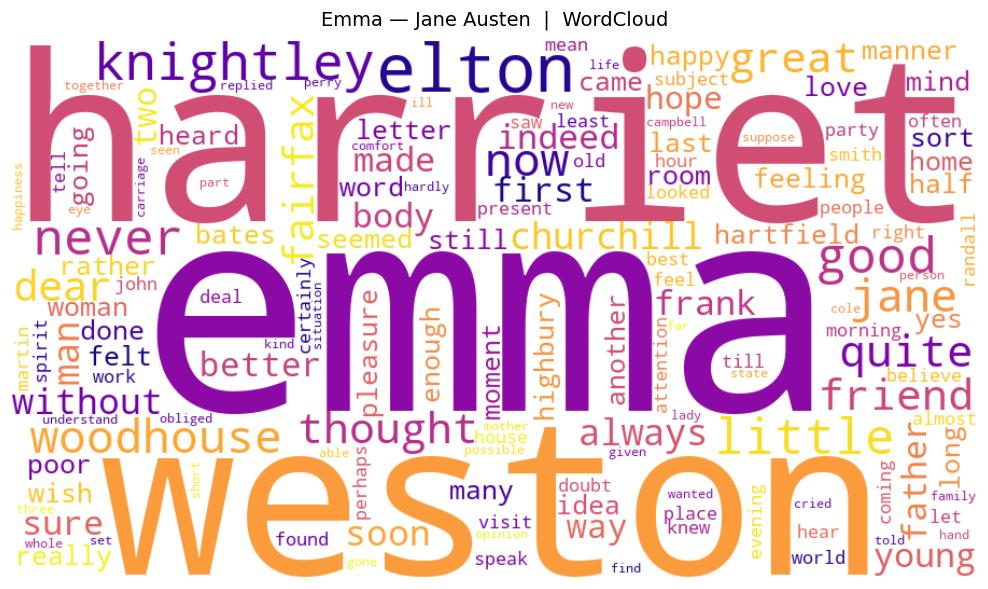

In [13]:
from urllib import request
import ssl
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

url = "https://www.gutenberg.org/cache/epub/158/pg158.txt"
response = request.urlopen(url, context=ctx)
raw = response.read().decode('utf8')

start = raw.find("VOLUME I")
end   = raw.find("End of the Project Gutenberg")
text  = raw[start:end]

# 불용어: 내장 사전 + 소설 특화 단어
stopwords = STOPWORDS | {'mr', 'mrs', 'miss', 'said', 'one','thing',
                          'would', 'could', 'must', 'though', 'every','will',
                          'much', 'well', 'upon', 'shall', 'away',
                          'also', 'even', 'yet', 'may', 'might', 'like',
                          'know', 'see', 'come', 'go', 'say', 'get',
                          'make', 'take', 'look', 'think', 'want', 'give',
                          'time', 'day', 'year', 
                          'chapter','project', 'gutenberg', 'ebook', 'vol', 'volume', 'end',
                          'nothing', 'everything', 'somebody', 'somewhere', 'anybody', 'anywhere',
                          'everybody', 'everywhere', 'nobody', 'nowhere', 'something'}

# 전처리
# 소유격 's 를 먼저 제거한 뒤 토크나이징
text_clean = re.sub(r"'s\b", '', text, flags=re.IGNORECASE)  # Emma's → Emma
text_clean = re.sub(r"'",    '', text_clean)                  # 남은 apostrophe 제거

words = re.findall(r'[a-zA-Z]+', text_clean)
filtered = [w.lower() for w in words
            if w.lower() not in stopwords and len(w) > 2]

wc = WordCloud(
    width=900, height=500,
    background_color='white',
    colormap='plasma',
    max_words=150,
    stopwords=stopwords,
    collocations=False
).generate(' '.join(filtered))

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title("Emma — Jane Austen  |  WordCloud", fontsize=14, pad=12)
plt.tight_layout()
plt.show()